# Margin of Victory Story

## The Election That Reshaped Tamil Nadu's Political Balance

### Research Question

How did the average margin of victory change between 2021 and 2026?

In how many constituencies did the winning candidate secure more than 50% of valid votes?

In how many constituencies did the winning candidate receive less than 35% of valid votes?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [8]:
df21 = pd.read_csv("../data/tn_2021_results.csv")
df26 = pd.read_csv("../data/tn_2026_results.csv")
master = pd.read_csv("../data/constituency_master.csv")

In [9]:
print(df_21.columns.tolist())

['constituency', 'ac_number', 'candidate', 'party', 'votes', 'turnout', 'reserved', 'region']


In [10]:
df21_sorted = df21.sort_values(
    ['ac_number', 'votes'],
    ascending=[True, False]
)

In [12]:
top2_21 = (
    df21_sorted
    .groupby('ac_number')
    .head(2)
)
top2_21

,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipundi,1,GOVINDARAJAN T.J,DMK,126452,78.08,GEN,Chennai Metro
1,Gummidipundi,1,PRAKASH M,PMK,75514,78.08,GEN,Chennai Metro
13,Ponneri,2,DURAI. CHANDRASEKAR,INC,94528,78.20,SC,Chennai Metro
14,Ponneri,2,BALARAMAN. P,AIADMK,84839,78.20,SC,Chennai Metro
24,Tiruttani,3,S.Chandran,DMK,120314,78.76,GEN,Chennai Metro
...,...,...,...,...,...,...,...,...
4189,Padmanabhapuram,232,"John Thankam, D.",AIADMK,60859,70.08,GEN,South
4201,Vilavancode,233,VIJAYADHARANI S,INC,87473,66.83,GEN,South
4202,Vilavancode,233,JAYASEELAN R,BJP,58804,66.83,GEN,South
4217,Killiyoor,234,RAJESH KUMAR S,INC,101541,65.87,GEN,South


In [14]:
margin21 = []

for ac, group in top2_21.groupby('ac_number'):

    winner = group.iloc[0]
    runner = group.iloc[1]

    total_votes = (
        df21[df21['ac_number'] == ac]
        ['votes']
        .sum()
    )

    margin_votes = winner['votes'] - runner['votes']

    margin_pct = (
        margin_votes / total_votes
    ) * 100

    winner_vote_share = (
        winner['votes'] / total_votes
    ) * 100

    margin21.append({
        'ac_number': ac,
        'constituency': winner['constituency'],
        'region': winner['region'],
        'reserved': winner['reserved'],
        'winner_candidate': winner['candidate'],
        'winner_party': winner['party'],
        'winner_votes': winner['votes'],
        'runner_votes': runner['votes'],
        'total_votes': total_votes,
        'margin_votes': margin_votes,
        'margin_pct': margin_pct,
        'winner_vote_share': winner_vote_share
    })

margin21 = pd.DataFrame(margin21)
margin21

,ac_number,constituency,region,reserved,winner_candidate,winner_party,winner_votes,runner_votes,total_votes,margin_votes,margin_pct,winner_vote_share
0,1,Gummidipundi,Chennai Metro,GEN,GOVINDARAJAN T.J,DMK,126452,75514,222069,50938,22.937916,56.942662
1,2,Ponneri,Chennai Metro,SC,DURAI. CHANDRASEKAR,INC,94528,84839,210354,9689,4.606045,44.937581
2,3,Tiruttani,Chennai Metro,GEN,S.Chandran,DMK,120314,91061,232624,29253,12.575229,51.720373
3,4,Thiruvallur,Chennai Metro,GEN,"RAAJENDRAN, V.G.",DMK,107709,85008,214243,22701,10.595912,50.274221
4,5,Poonamallee,Chennai Metro,SC,Krishnaswamy A,DMK,149578,55468,263736,94110,35.683411,56.715048
...,...,...,...,...,...,...,...,...,...,...,...,...
229,230,Nagercoil,South,GEN,Gandhi M.R.,BJP,88804,77135,184185,11669,6.335478,48.214567
230,231,Colachel,South,GEN,Prince J.G.,INC,90681,65849,182969,24832,13.571698,49.560855
231,232,Padmanabhapuram,South,GEN,"Mano Thangaraj, T.",DMK,87744,60859,170156,26885,15.800207,51.566798
232,233,Vilavancode,South,GEN,VIJAYADHARANI S,INC,87473,58804,167836,28669,17.081556,52.118139


In [15]:
df26_sorted = df26.sort_values(
    ['ac_number', 'votes'],
    ascending=[True, False]
)

top2_26 = (
    df26_sorted
    .groupby('ac_number')
    .head(2)
)
top2_26

,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipoondi,1,S.VIJAYAKUMAR,TVK,94320,NaN,GEN,Chennai Metro
1,Gummidipoondi,1,SUDHAKAR.V,AIADMK,66375,NaN,GEN,Chennai Metro
16,Ponneri,2,DR.RAVI.M.S,TVK,110439,NaN,SC,Chennai Metro
17,Ponneri,2,DURAI CHANDRASEKAR,INC,54671,NaN,SC,Chennai Metro
30,Tiruttani,3,G.HARI,AIADMK,89169,NaN,GEN,Chennai Metro
...,...,...,...,...,...,...,...,...
4217,Padmanabhapuram,232,KRISHNA KUMAR. S,TVK,53369,NaN,GEN,South
4228,Vilavancode,233,PRAVEEN T.T,INC,70755,NaN,GEN,South
4229,Vilavancode,233,MICHAEL KUMAR K,TVK,49785,NaN,GEN,South
4243,Killiyoor,234,RAJESH KUMAR. S,INC,66434,NaN,GEN,South


In [16]:
margin26 = []

for ac, group in top2_26.groupby('ac_number'):

    winner = group.iloc[0]
    runner = group.iloc[1]

    total_votes = (
        df26[df26['ac_number'] == ac]
        ['votes']
        .sum()
    )

    margin_votes = winner['votes'] - runner['votes']

    margin_pct = (
        margin_votes / total_votes
    ) * 100

    winner_vote_share = (
        winner['votes'] / total_votes
    ) * 100

    margin26.append({
        'ac_number': ac,
        'constituency': winner['constituency'],
        'region': winner['region'],
        'reserved': winner['reserved'],
        'winner_candidate': winner['candidate'],
        'winner_party': winner['party'],
        'winner_votes': winner['votes'],
        'runner_votes': runner['votes'],
        'total_votes': total_votes,
        'margin_votes': margin_votes,
        'margin_pct': margin_pct,
        'winner_vote_share': winner_vote_share
    })

margin26 = pd.DataFrame(margin26)

In [18]:
margin21.head(3)

margin26.head(3)

,ac_number,constituency,region,reserved,winner_candidate,winner_party,winner_votes,runner_votes,total_votes,margin_votes,margin_pct,winner_vote_share
0,1,Gummidipoondi,Chennai Metro,GEN,S.VIJAYAKUMAR,TVK,94320,66375,232522,27945,12.018218,40.563904
1,2,Ponneri,Chennai Metro,SC,DR.RAVI.M.S,TVK,110439,54671,226819,55768,24.587005,48.690365
2,3,Tiruttani,Chennai Metro,GEN,G.HARI,AIADMK,89169,83376,238798,5793,2.425900,37.340765


In [19]:
margin21["year"] = 2021
margin26["year"] = 2026

In [20]:
margin = pd.concat(
    [margin21, margin26],
    ignore_index=True
)

## Question 1
### How did the average margin of victory change?

In [22]:
avg_margin = (
    margin.groupby("year")["margin_pct"]
    .mean()
    .reset_index()
)

avg_margin

,year,margin_pct
0,2021,11.69629
1,2026,7.67234


C:\Users\LMES-LP\AppData\Local\Temp\ipykernel_19380\4061780869.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


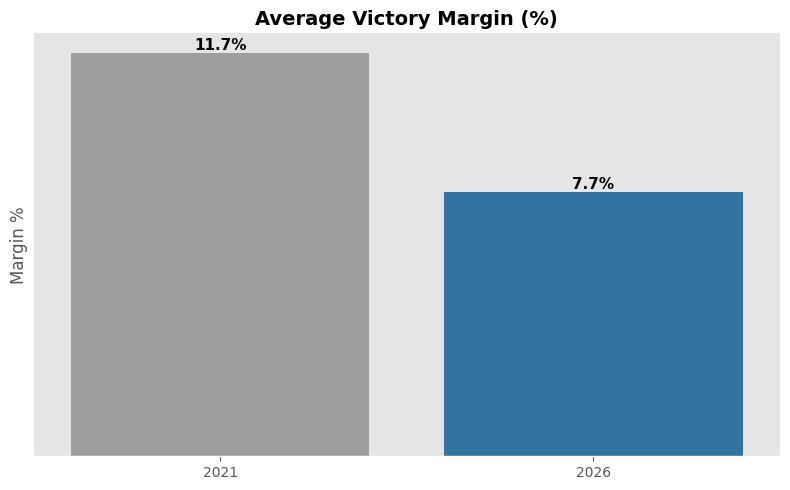

In [24]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=avg_margin,
    x="year",
    y="margin_pct",
    palette=["#9E9E9E", "#1F77B4"]  # 2021 Grey, 2026 Blue
)

# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Average Victory Margin (%)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Margin %")
plt.xlabel("")

# Remove y-axis if you want a cleaner dashboard look
plt.yticks([])

sns.despine(left=True)

plt.tight_layout()
plt.show()

## Winner Vote Share Distribution

This section examines how many winners secured a majority of votes and how many won with less than 35% vote share.

In [25]:
def vote_band(x):

    if x < 35:
        return "Less than 35%"

    elif x <= 50:
        return "35% - 50%"

    else:
        return "More than 50%"

In [27]:
margin["vote_band"] = (
    margin["winner_vote_share"]
    .apply(vote_band)
)

In [28]:
band_summary = (
    margin.groupby(
        ["year", "vote_band"]
    )
    .size()
    .reset_index(name="Seats")
)

band_summary

,year,vote_band,Seats
0,2021,35% - 50%,162
1,2021,Less than 35%,2
2,2021,More than 50%,70
3,2026,35% - 50%,157
4,2026,Less than 35%,64
5,2026,More than 50%,13


In [30]:
band_pct = (
    band_summary
    .pivot(
        index="year",
        columns="vote_band",
        values="Seats"
    )
)

band_pct

vote_band,35% - 50%,Less than 35%,More than 50%
year,,,
2021,162,2,70
2026,157,64,13


In [31]:
band_pct = (
    band_pct
    .div(
        band_pct.sum(axis=1),
        axis=0
    )
    * 100
)

band_pct

vote_band,35% - 50%,Less than 35%,More than 50%
year,,,
2021,69.230769,0.854701,29.914530
2026,67.094017,27.350427,5.555556


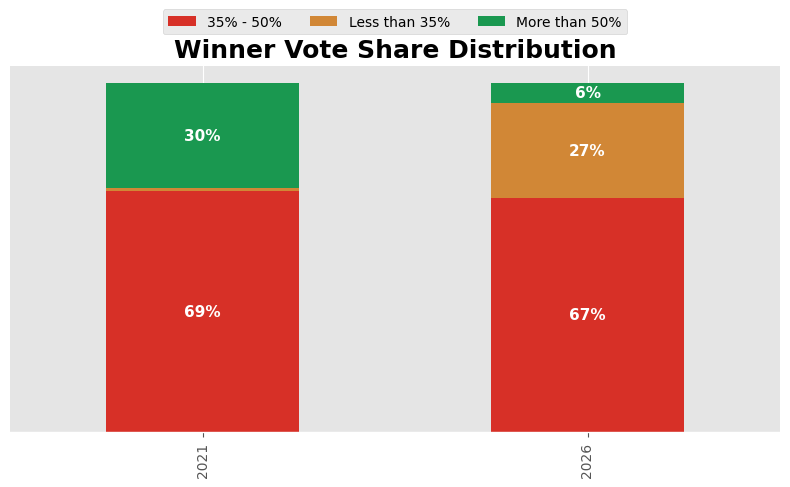

In [33]:
fig, ax = plt.subplots(figsize=(8,5))

band_pct.plot(
    kind="bar",
    stacked=True,
    color=[
        "#D73027",  # <35%
        "#D18736",  # 35-50%
        "#1A9850"   # >50%
    ],
    ax=ax
)

# Add percentage labels
for container in ax.containers:

    labels = []

    for value in container.datavalues:

        if value >= 3:      # hide tiny segments
            labels.append(f"{value:.0f}%")
        else:
            labels.append("")

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Winner Vote Share Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("")
plt.xlabel("")

plt.yticks([])

plt.legend(
    title="",
    ncol=3,
    bbox_to_anchor=(0.5, 1.12),
    loc="center"
)

sns.despine(left=True)

plt.tight_layout()

plt.show()

# Conclusion

The 2026 election produced narrower victory margins than 2021, indicating a more competitive electoral landscape.

Only 6% of constituencies were won with more than 50% of the vote in 2026, compared with 30% in 2021.

At the same time, the share of constituencies won with less than 35% vote share increased from almost none in 2021 to 27% in 2026.

Together, these patterns suggest that winning candidates in 2026 generally secured smaller electoral mandates and faced stronger competition across constituencies.